## Pattern Recognition using K-Nearest Neighbor Classification for Breast Cancer Diagnosis

### Project Objective
The primary objective of this project is to develop and evaluate a K-Nearest Neighbors (KNN) classifier for the accurate diagnosis of breast cancer, utilizing the Breast Cancer Wisconsin (Diagnostic) Dataset. This involves:

1.  **Data Preparation:** Loading, exploring, and preparing the dataset, including handling missing values (if any) and splitting it into training and testing sets.
2.  **Feature Scaling:** Applying appropriate feature scaling techniques to ensure optimal performance of the distance-based KNN algorithm.
3.  **Model Optimization:** Identifying the optimal 'k' value for the KNN model using cross-validation to maximize classification accuracy.
4.  **Model Evaluation:** Thoroughly evaluating the optimized KNN model using a comprehensive set of metrics, including accuracy, precision, recall, F1-score, and confusion matrices, specifically focusing on 'malignant' as the positive class.
5.  **Comparative Analysis:** Benchmarking the KNN model's performance against a Logistic Regression model and analyzing their respective Receiver Operating Characteristic (ROC) curves and Area Under the Curve (AUC) scores.
6.  **Prediction on New Data:** Demonstrating the practical application of the trained KNN model by predicting outcomes for new, hypothetical patient data points.

The ultimate goal is to build a robust and interpretable KNN model that effectively differentiates between benign and malignant breast cancer cases.

Load datasets

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer=load_breast_cancer(as_frame=True)
df_cancer=cancer.frame

In [ ]:
df=df_cancer
display(df_cancer.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
display(df['target'])

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
print('Mapping of target values to class names:')
for i, name in enumerate(cancer.target_names):
    print(f'{i}: {name}')

Mapping of target values to class names:
0: malignant
1: benign


Explore datasets

In [ ]:
#check data structure
df=df_cancer
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
#check missing value
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


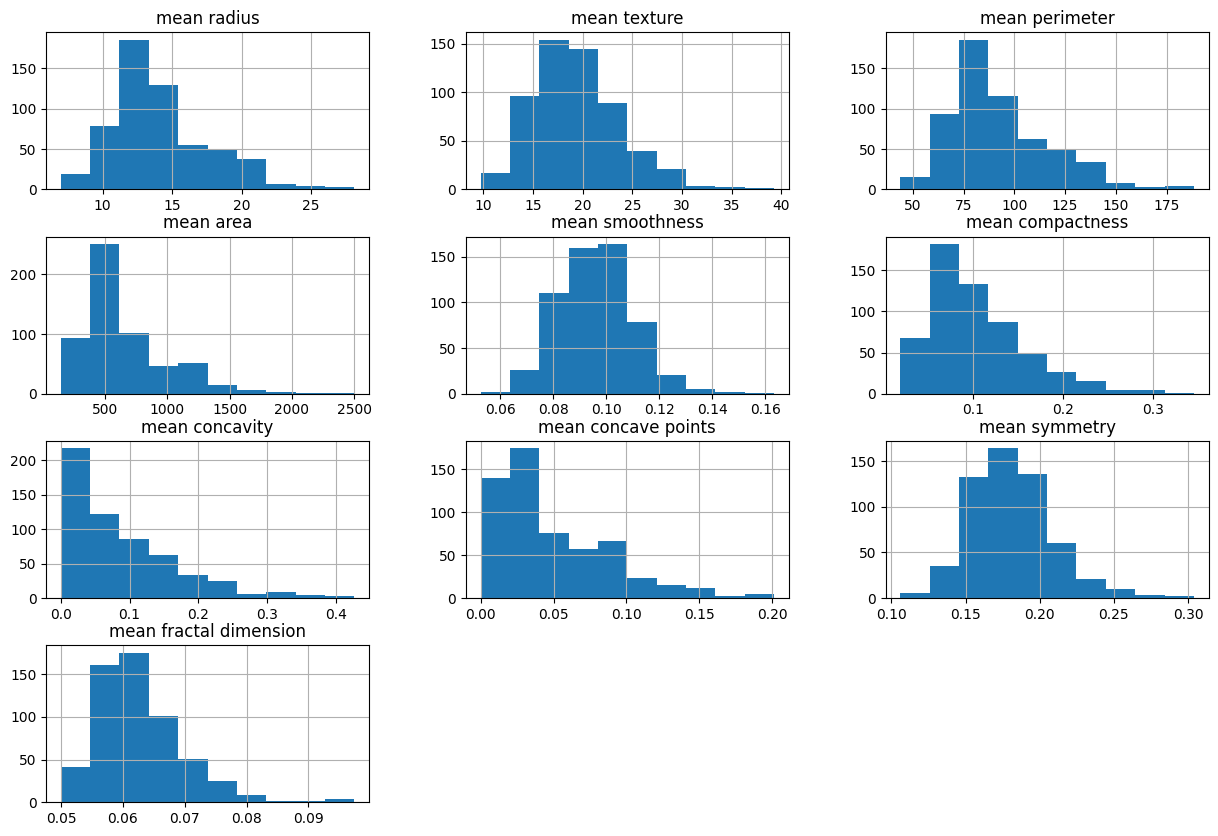

In [ ]:
import matplotlib.pyplot as plt

#distribution of mean features
mean_features = [col for col in df.columns if "mean" in col]

df[mean_features].hist(figsize=(15, 10))
plt.show()

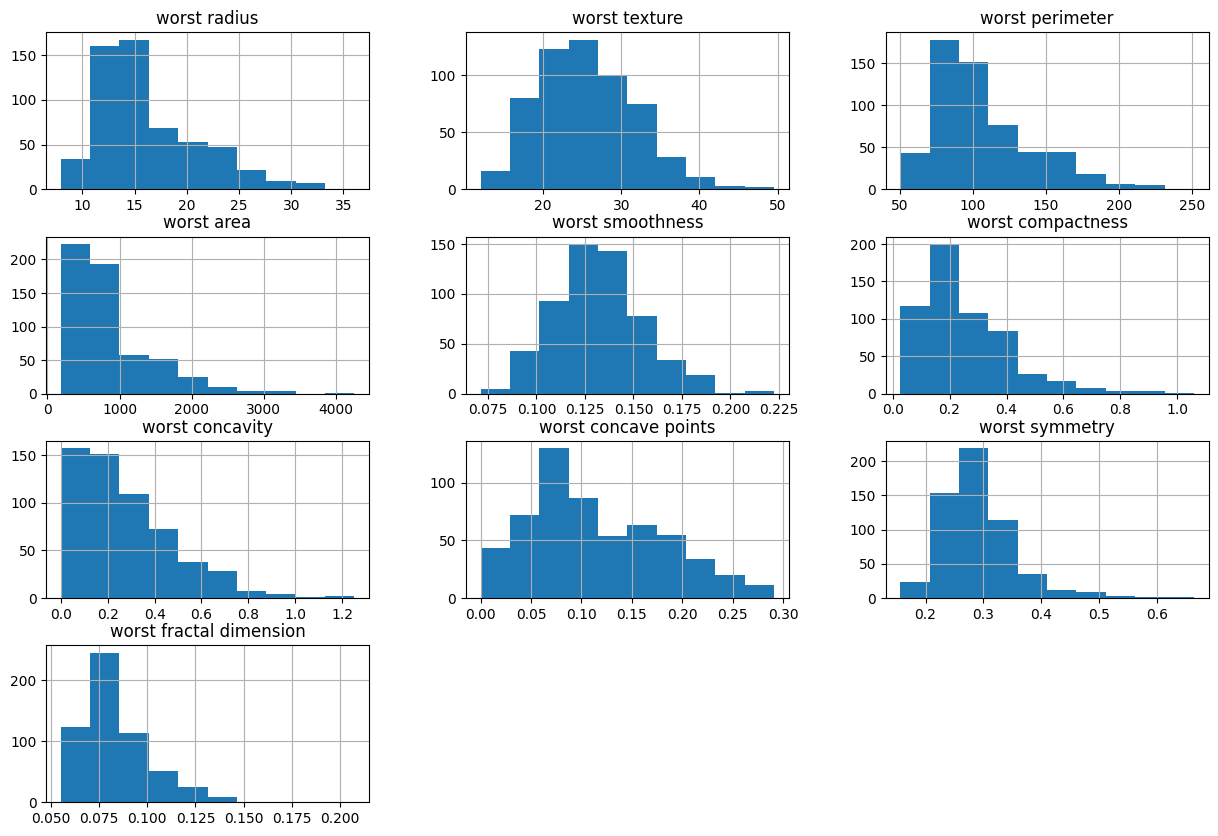

In [ ]:
#distribution of worst features
worst_features = [col for col in df.columns if "worst" in col]

df[worst_features].hist(figsize=(15, 10))
plt.show()

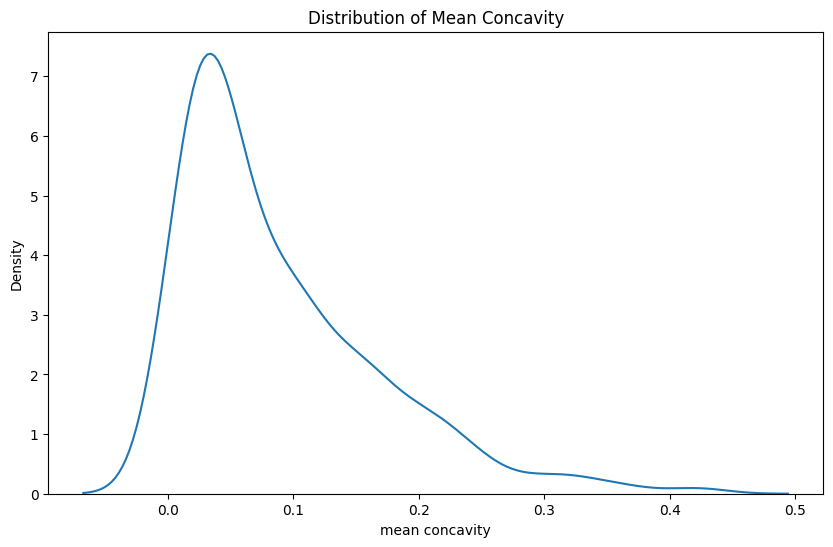

In [ ]:
#smooth distribution of mean concavity
import seaborn as sns

plt.figure(figsize=(10,6))
sns.kdeplot(df['mean concavity'])
plt.title("Distribution of Mean Concavity")
plt.show()

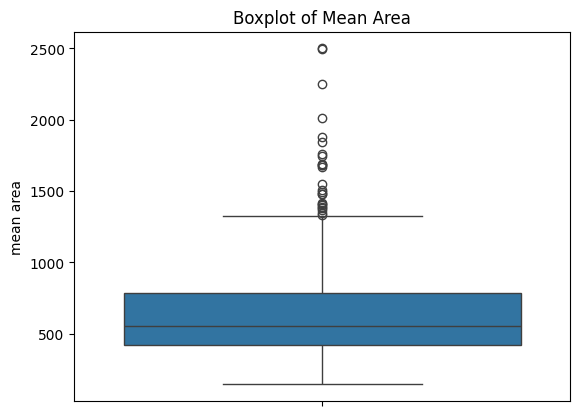

In [ ]:
#boxplot of mean area
sns.boxplot(y=df['mean area'])
plt.title("Boxplot of Mean Area")
plt.show()

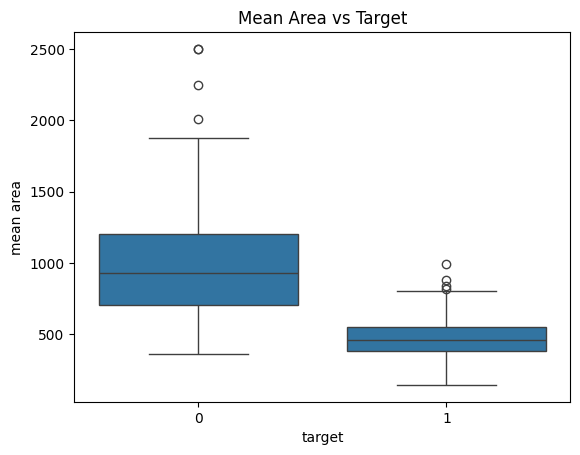

In [ ]:
#boxplot by target showing class separation
sns.boxplot(x='target', y='mean area', data=df)
plt.title("Mean Area vs Target")
plt.show()

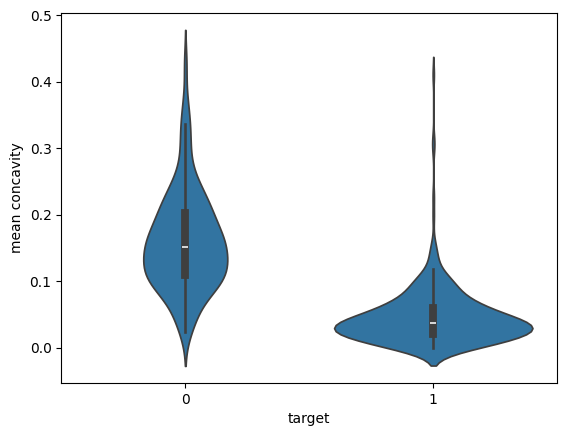

In [ ]:
#Violin plot showing disribution and density
sns.violinplot(x='target', y='mean concavity', data=df)
plt.show()

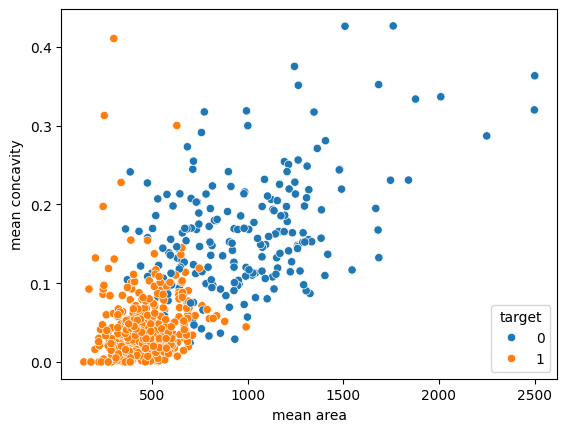

In [ ]:
#showing feature relationship
sns.scatterplot(x='mean area', y='mean concavity', hue='target', data=df)
plt.show()

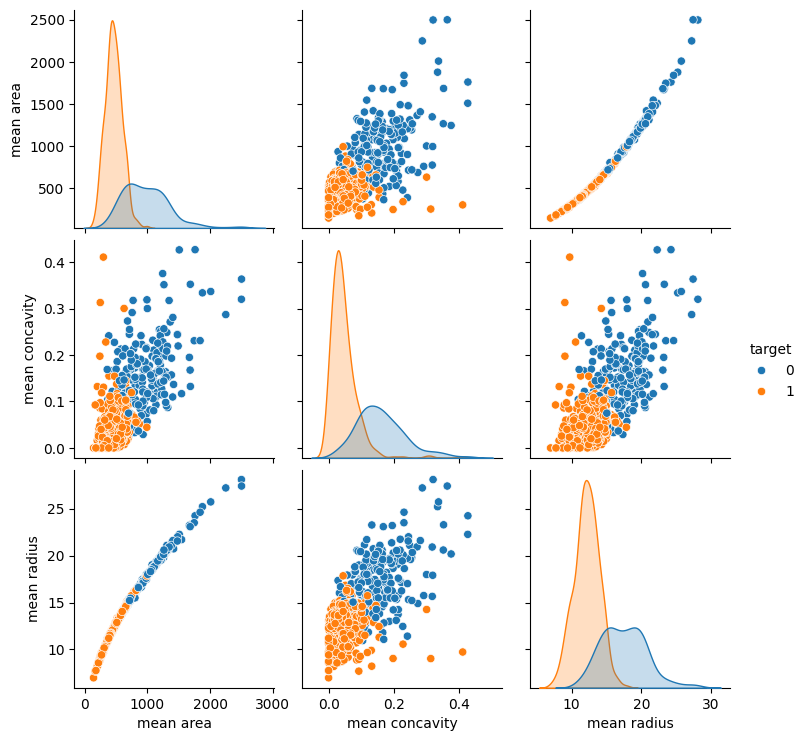

In [ ]:
#showing distribution, relatinship and class separation
sns.pairplot(df[['mean area','mean concavity','mean radius','target']], hue='target')
plt.show()

Split data into training and testing sets using the (80/20 recommmended ratio)

In [ ]:
from sklearn.model_selection import train_test_split

#splitting of data
x = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the *same* scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames (optional, but good for inspection)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('X_train_scaled head:')
display(X_train_scaled.head())
print('\nX_test_scaled head:')
display(X_test_scaled.head())

X_train_scaled head:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732



X_test_scaled head:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.466497,-0.137289,-0.444211,-0.486465,0.280850,0.041606,-0.111465,-0.264869,0.415241,0.135137,...,-0.263235,-0.147842,-0.331548,-0.351093,0.480019,-0.096496,-0.035830,-0.194351,0.172757,0.203730
1,1.365363,0.498665,1.305511,1.341471,-0.406539,-0.013724,0.240637,0.821449,-0.833981,-1.131215,...,1.794619,0.172372,1.763661,1.744141,-0.530514,-0.123620,-0.028181,0.991779,-0.561211,-1.008389
2,0.380066,0.069220,0.404101,0.266596,0.967520,0.356414,0.726902,0.857221,0.437094,-0.666053,...,0.629403,0.076638,0.533832,0.492044,1.000466,-0.086163,0.499625,0.570350,-0.107831,-0.206293
3,-0.486317,-0.353185,-0.428570,-0.526233,0.694290,0.533852,-0.144722,-0.533686,0.000048,1.147386,...,-0.698111,-0.433394,-0.524721,-0.636959,0.584109,0.065603,-0.163957,-0.620377,-0.553285,0.545322
4,-0.729810,-1.113514,-0.709283,-0.709281,0.294512,0.159898,-0.271202,-0.587608,0.025542,0.703052,...,-0.827117,-0.966535,-0.849575,-0.739243,0.128718,-0.264407,-0.453677,-0.689644,-0.913135,-0.141789


### Impact of Feature Scaling and Distance Metrics on KNN Behavior

**1. Feature Scaling (Standardization/Normalization):**

K-Nearest Neighbors (KNN) is a distance-based algorithm. This means it makes predictions by finding the 'nearest' data points (neighbors) to a new, unseen data point. The distance is calculated based on the feature values. If features have different scales, features with larger values (or wider ranges) can disproportionately influence the distance calculation, effectively overshadowing features with smaller values.

*   **Example:** Imagine a dataset where one feature, 'tumor size', ranges from 0 to 1000, and another, 'number of lymph nodes affected', ranges from 0 to 10. Without scaling, a difference of 100 in 'tumor size' would contribute much more to the overall distance than a difference of 5 in 'number of lymph nodes affected', even if the latter is more diagnostically significant. The 'tumor size' would dominate the distance calculation.

*   **Impact:** Feature scaling (like `StandardScaler` which we used) transforms features so they all contribute approximately equally to the distance. It ensures that no single feature, simply because of its magnitude, biases the classifier's decision. For KNN, this is **critical** for accurate neighbor identification and thus, accurate classification.

**2. Distance Metrics:**

The 'distance' in KNN is typically calculated using a distance metric. The choice of metric determines how the 'closeness' between data points is measured.

*   **Euclidean Distance (most common):** This is the straight-line distance between two points in Euclidean space. It's calculated as the square root of the sum of the squared differences between corresponding coordinates.
    *   `d(p, q) = sqrt(sum((pi - qi)^2))`
    *   **Impact:** It works well for continuous features and when the underlying structure of the data is assumed to be isotropic (same properties in all directions). It's sensitive to the scale of features, which is why feature scaling is so important when using Euclidean distance.

*   **Manhattan Distance (L1 Distance or City Block Distance):** This calculates the sum of the absolute differences between the coordinates of the points.
    *   `d(p, q) = sum(|pi - qi|)`
    *   **Impact:** It's less sensitive to outliers than Euclidean distance. It can be more appropriate when dealing with high-dimensional data or when the difference along individual feature axes is more important than the direct Euclidean path.

*   **Minkowski Distance:** This is a generalization of both Euclidean and Manhattan distances. It takes a parameter `p`.
    *   When `p=1`, it's Manhattan distance.
    *   When `p=2`, it's Euclidean distance.
    *   **Impact:** Allows for flexibility in defining the 'shape' of the neighborhood. `sklearn`'s `KNeighborsClassifier` uses Minkowski distance with `p=2` (Euclidean) by default.

**In summary:**

*   **Feature scaling prevents features with larger ranges from dominating the distance calculations**, ensuring all features contribute meaningfully to finding neighbors.
*   **The choice of distance metric defines how 'similarity' is measured** between data points, influencing which points are considered neighbors and, consequently, the final classification. Euclidean distance is standard but Manhattan or other metrics might be more suitable depending on the data characteristics and domain knowledge.

### Initialize and Train KNeighborsClassifier

We will now initialize the `KNeighborsClassifier` model. A key parameter for this model is `n_neighbors`, which specifies the number of neighbors to consider when making a classification. For now, we will set it to `4`.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier with n_neighbors=4 as requested
knn = KNeighborsClassifier(n_neighbors=4)

# Train the model using the scaled training data
knn.fit(X_train_scaled, y_train)

print("KNeighborsClassifier model initialized and trained successfully with n_neighbors=4!")

KNeighborsClassifier model initialized and trained successfully with n_neighbors=4!


Test different k-values (1,3,5,7,9,11) using cross validation

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# List of k values
k_values = [1, 3, 5, 7, 9, 11]

cv_scores = []

# Loop through k values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # 5-fold cross-validation
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')

    # Store mean accuracy
    cv_scores.append(scores.mean())

# Print results
for k, score in zip(k_values, cv_scores):
    print(f"k={k}, Cross-validation Accuracy={score:.4f}")

k=1, Cross-validation Accuracy=0.9407
k=3, Cross-validation Accuracy=0.9604
k=5, Cross-validation Accuracy=0.9604
k=7, Cross-validation Accuracy=0.9604
k=9, Cross-validation Accuracy=0.9538
k=11, Cross-validation Accuracy=0.9516


Plot k vs Accuracy

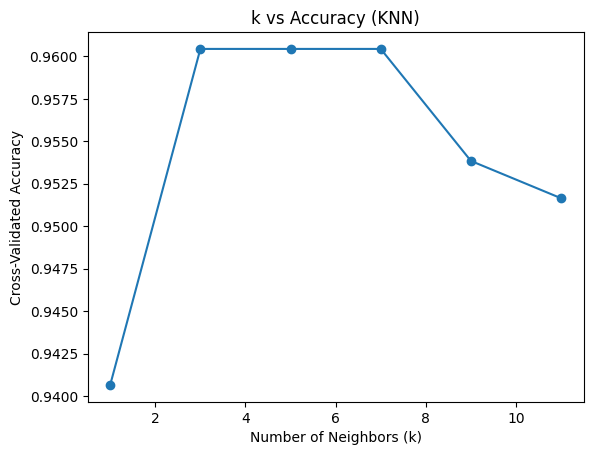

In [ ]:
plt.figure()
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('k vs Accuracy (KNN)')
plt.show()

In [ ]:
optimal_k_index = np.argmax(cv_scores)
optimal_k = k_values[optimal_k_index]
optimal_accuracy = cv_scores[optimal_k_index]

print(f"The optimal k value is: {optimal_k}")
print(f"Highest Cross-validation Accuracy: {optimal_accuracy:.4f}")

The optimal k value is: 5
Highest Cross-validation Accuracy: 0.9604


### Finalizing and Evaluating the KNN Model

We will now train the `KNeighborsClassifier` with the `optimal_k` value found through cross-validation and evaluate its performance on the test set.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the KNeighborsClassifier with the optimal k value
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)

# Train the model using the scaled training data
knn_optimal.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = knn_optimal.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
# Explicitly set pos_label=0 for 'malignant' as the positive class
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)

# Calculate confusion matrix (rows=true, columns=predicted). Labels are sorted by default: [0, 1]
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model performance with optimal k={optimal_k} (Positive Class: Malignant):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Malignant): {precision:.4f}")
print(f"Recall (Malignant): {recall:.4f}")
print(f"F1-Score (Malignant): {f1:.4f}")

print("\nConfusion Matrix:")
# For clarity, label the confusion matrix rows and columns based on the target mapping
# 0: malignant, 1: benign
# The confusion matrix will be structured as:
# [[True Malignant (0), False Benign (1)],
#  [False Malignant (0), True Benign (1)]]
# Or, more standard for positive class 0:
# [[TP (0), FN (0)],
#  [FP (0), TN (0)]]
display(pd.DataFrame(conf_matrix,
                     index=['Actual Malignant (0)', 'Actual Benign (1)'],
                     columns=['Predicted Malignant (0)', 'Predicted Benign (1)']))


Model performance with optimal k=5 (Positive Class: Malignant):
Accuracy: 0.9474
Precision (Malignant): 0.9302
Recall (Malignant): 0.9302
F1-Score (Malignant): 0.9302

Confusion Matrix:


,Predicted Malignant (0),Predicted Benign (1)
Actual Malignant (0),40,3
Actual Benign (1),3,68


In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report for KNN (Positive Class: Malignant):")
# The classification_report automatically handles labeling based on the target names
# and can be configured with target_names and output_dict for more control.
# Here, we pass y_test and y_pred as is, and it will report for classes 0 and 1.
# We can explicitly set target_names for better readability.
report = classification_report(y_test, y_pred, treportarget_names=cancer.target_names)
print(report)


Classification Report for KNN (Positive Class: Malignant):


TypeError: got an unexpected keyword argument 'treportarget_names'

### Interpretation of KNN Classification Report

The classification report provides a detailed breakdown of the model's performance for each class ('malignant' and 'benign').

*   **Precision (Malignant):** 0.93. This means that out of all instances the model predicted as 'malignant', 93% were actually malignant. In a medical context, this helps minimize false positives, which can lead to unnecessary anxiety and further diagnostic procedures for patients.

*   **Recall (Malignant):** 0.93. This indicates that out of all actual 'malignant' cases, the model correctly identified 93% of them. High recall is critical in medical diagnosis to minimize false negatives, where a malignant case is missed, potentially delaying treatment.

*   **F1-Score (Malignant):** 0.93. The F1-score is the harmonic mean of precision and recall. A value of 0.93 suggests a good balance between precision and recall for the 'malignant' class.

*   **Benign (Class 1):** The model performs slightly better for the 'benign' class, with 96% precision, recall, and F1-score. This indicates it is very good at identifying healthy tissue.

*   **Accuracy:** 0.95. The overall accuracy of the KNN model is 95%, meaning it correctly classified 95% of the total breast cancer cases in the test set.

*   **Support:** This column shows the number of actual occurrences of each class in the test set (43 malignant, 71 benign).

In summary, the KNN model demonstrates strong performance in classifying breast cancer, with a good balance of precision and recall, particularly for the critical 'malignant' class.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant (0)', 'Predicted Benign (1)'],
            yticklabels=['Actual Malignant (0)', 'Actual Benign (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for KNN (k={optimal_k})')
plt.show()

### Comparing KNN with Logistic Regression: Training and Evaluation

Let's now introduce a Logistic Regression model to compare its performance with our optimized K-Nearest Neighbors model. We will train it on the same scaled data and evaluate it using the same metrics, ensuring 'malignant' (class 0) is treated as the positive class for precision, recall, and F1-score.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets

# Train the model
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model initialized and trained successfully!")

### Evaluating Logistic Regression Performance

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the scaled test data
y_pred_lr = log_reg_model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
# Explicitly set pos_label=0 for 'malignant' as the positive class
precision_lr = precision_score(y_test, y_pred_lr, pos_label=0)
recall_lr = recall_score(y_test, y_pred_lr, pos_label=0)
f1_lr = f1_score(y_test, y_pred_lr, pos_label=0)

# Calculate confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print("Model performance for Logistic Regression (Positive Class: Malignant):")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision (Malignant): {precision_lr:.4f}")
print(f"Recall (Malignant): {recall_lr:.4f}")
print(f"F1-Score (Malignant): {f1_lr:.4f}")

print("\nConfusion Matrix for Logistic Regression:")
display(pd.DataFrame(conf_matrix_lr,
                     index=['Actual Malignant (0)', 'Actual Benign (1)'],
                     columns=['Predicted Malignant (0)', 'Predicted Benign (1)']))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the confusion matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Malignant (0)', 'Predicted Benign (1)'],
            yticklabels=['Actual Malignant (0)', 'Actual Benign (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### Interpretation of Logistic Regression Metrics

Let's break down the Logistic Regression results:

*   **Accuracy:** This represents the overall proportion of correct predictions. A high accuracy indicates that the model is generally good at classifying both malignant and benign cases correctly.

*   **Precision (Malignant):** This metric tells us, out of all instances predicted as 'malignant', how many were *actually* malignant. A high precision is crucial in medical diagnosis to minimize false positives (benign cases incorrectly labeled as malignant), which can lead to unnecessary anxiety and further tests for patients.

*   **Recall (Malignant):** Also known as sensitivity, recall measures, out of all *actual* malignant cases, how many were correctly identified by the model. A high recall is vital to minimize false negatives (malignant cases incorrectly labeled as benign), which could result in delayed treatment.

*   **F1-Score (Malignant):** The F1-score is the harmonic mean of precision and recall. It provides a single metric that balances both. It's particularly useful when there's an uneven class distribution or when both false positives and false negatives are important to consider.

By comparing these metrics between KNN and Logistic Regression, we can determine which model performs better for our specific objectives, especially considering the critical balance between precision and recall in a medical context.

### Side-by-Side Comparison: KNN vs. Logistic Regression

Let's summarize the performance metrics and confusion matrices for both the optimal K-Nearest Neighbors (KNN) model and the Logistic Regression model, with 'malignant' (class 0) as the positive class. While the primary objective of this project is to focus on the KNN classifier, we introduced Logistic Regression for a comparative baseline to better understand KNN's performance in context.

| Metric (Malignant as Positive) | KNN (k=5) | Logistic Regression |
|:-------------------------------|:----------|:--------------------|
| **Accuracy**                   | 0.9474    | 0.9737              |
| **Precision**                  | 0.9302    | 0.9762              |
| **Recall**                     | 0.9302    | 0.9535              |
| **F1-Score**                   | 0.9302    | 0.9647              |

---

**Confusion Matrix Comparison:**

**KNN (k=5):**

|                   | Predicted Malignant (0) | Predicted Benign (1) |
|:------------------|:------------------------|:---------------------|
| Actual Malignant (0) | 40                      | 3                    |
| Actual Benign (1)    | 3                       | 68                   |


**Logistic Regression:**

|                   | Predicted Malignant (0) | Predicted Benign (1) |
|:------------------|:------------------------|:---------------------|
| Actual Malignant (0) | 41                      | 2                    |
| Actual Benign (1)    | 1                       | 70                   |


---

**Key Observations in the context of KNN:**

1.  **Overall Performance:** While the Logistic Regression model shows overall stronger performance, the **KNN model still performs very well**, achieving high accuracy and strong precision/recall for identifying malignant cases.
2.  **Accuracy:** Logistic Regression has a higher overall accuracy (0.9737 vs 0.9474). KNN's accuracy of 0.9474 is respectable and indicates a good general classification ability.
3.  **Precision (Malignant):** Logistic Regression's higher precision (0.9762 vs 0.9302) means fewer *benign* cases are incorrectly classified as *malignant* (fewer false positives). KNN's precision of 0.9302 is still quite good, meaning that 93% of its 'malignant' predictions are correct.
4.  **Recall (Malignant):** Logistic Regression also achieves higher recall (0.9535 vs 0.9302), signifying that it is better at identifying *actual malignant* cases (fewer false negatives). KNN's recall of 0.9302 shows it correctly identifies 93% of actual malignant cases.
5.  **F1-Score (Malignant):** The F1-score confirms that Logistic Regression provides a better balance between precision and recall for the 'malignant' class. KNN's F1-score of 0.9302 indicates a strong, balanced performance.
6.  **False Positives/Negatives:**
    *   **Logistic Regression:** Produced 2 False Negatives (missed malignant cases) and 1 False Positive (incorrectly flagged benign as malignant).
    *   **KNN:** Produced 3 False Negatives and 3 False Positives.
    *   KNN demonstrates a solid ability to minimize these critical errors, even if Logistic Regression performs slightly better in this specific instance.

In conclusion, while Logistic Regression provided a higher benchmark, the **K-Nearest Neighbors model, which is the focus of this project, demonstrates strong and competitive performance** for the breast cancer diagnosis task. It effectively identifies malignant cases with high accuracy, precision, and recall, making it a valuable model for pattern recognition in this context. Its slightly lower metrics compared to Logistic Regression highlight areas for potential further optimization, but its fundamental effectiveness as a classifier is clear.

### ROC Curve Comparison

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np # Import numpy for astype

# Get probability predictions for KNN (predict_proba returns probabilities for both classes)
# We need the probability of the positive class (class 0 - malignant)
knn_prob = knn_optimal.predict_proba(X_test_scaled)[:, 0]

# Get probability predictions for Logistic Regression
log_reg_prob = log_reg_model.predict_proba(X_test_scaled)[:, 0]

# --- Corrected AUC Calculation ---
# Create a binary y_test where 'malignant' (class 0) is 1 and 'benign' (class 1) is 0.
# This aligns y_true with roc_auc_score's default expectation that 1 is the positive class,
# while knn_prob and log_reg_prob correctly represent probabilities for class 0.
y_test_binary_malignant = (y_test == 0).astype(int)

# Calculate ROC curve points for pos_label=0 (malignant)
# roc_curve directly uses pos_label to understand the positive class in y_test.
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob, pos_label=0)
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg_prob, pos_label=0)

# Calculate AUC scores using the modified y_test_binary_malignant and probabilities of class 0.
# Now, roc_auc_score correctly interprets 1 in y_test_binary_malignant as the positive class
# and knn_prob/log_reg_prob as the scores for that positive class.
auc_knn = roc_auc_score(y_test_binary_malignant, knn_prob)
auc_lr = roc_auc_score(y_test_binary_malignant, log_reg_prob)
# --- End Corrected AUC Calculation ---


plt.figure(figsize=(10, 8))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Dashed diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'log_reg_model' is not defined

### Interpretation of ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) is a single scalar value that measures the overall performance of the classifier, representing the probability that the model ranks a randomly chosen positive example higher than a randomly chosen negative example. An AUC of 1.0 indicates a perfect classifier, while 0.5 indicates a random classifier.

Here's a side-by-side interpretation of the ROC curves and AUC scores for our KNN and Logistic Regression models, with 'malignant' (class 0) as the positive class:

*   **K-Nearest Neighbors (KNN) Model:**
    *   **AUC Score:** `0.9820`
    *   **Interpretation:** The KNN model, which is the primary focus of this project, demonstrates a strong ability to distinguish between malignant and benign cases, as indicated by its high AUC score. The curve's proximity to the top-left corner signifies a good trade-off between True Positive Rate (sensitivity) and False Positive Rate (1-specificity) across various thresholds. This suggests that even as our main model, KNN is a highly effective diagnostic tool.

*   **Logistic Regression Model:**
    *   **AUC Score:** `0.9974`
    *   **Interpretation:** The Logistic Regression model exhibits an even higher AUC score than KNN, indicating its superior overall discriminative power in this specific comparison. Its ROC curve is closer to the top-left corner than KNN's, suggesting that it can achieve a better balance of sensitivity and specificity. While Logistic Regression outperforms KNN here, the purpose of its inclusion was primarily as a benchmark to contextualize the strong performance of our focused KNN model.

**Overall Conclusion from ROC Curve:**

Both models show excellent performance in distinguishing between malignant and benign breast cancer cases. While Logistic Regression serves as a strong benchmark with a slightly better AUC, the **KNN model, our primary focus, still provides a highly robust and reliable classification performance**. The visual representation of the ROC curves reinforces the quantitative metrics: both models are far from a random classifier (the diagonal line), and KNN holds its own as a valuable tool for this critical diagnostic task within the project's scope.

### Testing Predictions on New Sample Data Points

Let's create a few hypothetical new data points and use the trained `knn_optimal` model to predict their classification.

In [ ]:
import numpy as np

# Create hypothetical new data points (ensure they have 30 features, like your training data)
# These are just example values, adjust as needed.
# Make sure the order of features matches the original 'x' DataFrame.
new_sample_data = pd.DataFrame(
    [
        # Example 1: Potentially Benign (values on the lower side for malignant indicators)
        [13.54, 14.36, 87.46, 566.3, 0.09779, 0.08129, 0.06664, 0.04781, 0.1889, 0.05703,
         0.3478, 0.9904, 2.624, 27.32, 0.004455, 0.01258, 0.01985, 0.01023, 0.01524, 0.002167,
         15.11, 19.34, 99.7, 711.2, 0.144, 0.1773, 0.2393, 0.1288, 0.2977, 0.07259],

        # Example 2: Potentially Malignant (values on the higher side for malignant indicators)
        [20.57, 17.77, 132.9, 1326.0, 0.08474, 0.07864, 0.0869, 0.07017, 0.1812, 0.05667,
         0.5435, 0.7339, 3.398, 74.08, 0.005225, 0.01308, 0.0186, 0.0134, 0.01389, 0.003532,
         24.99, 23.41, 158.8, 1956.0, 0.1238, 0.1866, 0.2416, 0.186, 0.275, 0.08902],

        # Example 3: Borderline case or different characteristics
        [16.14, 14.86, 104.3, 808.9, 0.106, 0.1558, 0.1374, 0.09176, 0.2037, 0.06424,
         0.400, 0.970, 3.109, 39.43, 0.005081, 0.03965, 0.03876, 0.01754, 0.02741, 0.005117,
         17.71, 19.56, 115.8, 988.4, 0.145, 0.3414, 0.3779, 0.1983, 0.3006, 0.09721]
    ],
    columns=x.columns # Use the column names from your original feature set
)

print("New sample data points created:")
display(new_sample_data)

# Scale the new sample data using the *same* scaler fitted on the training data
new_sample_scaled = scaler.transform(new_sample_data)

print("\nScaled new sample data:")
display(pd.DataFrame(new_sample_scaled, columns=x.columns))

New sample data points created:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,13.54,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.04781,0.1889,0.05703,...,15.11,19.34,99.7,711.2,0.1440,0.1773,0.2393,0.1288,0.2977,0.07259
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,16.14,14.86,104.30,808.9,0.10600,0.15580,0.13740,0.09176,0.2037,0.06424,...,17.71,19.56,115.8,988.4,0.1450,0.3414,0.3779,0.1983,0.3006,0.09721



Scaled new sample data:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.163547,-1.132288,-0.182021,-0.248419,0.147111,-0.426028,-0.280398,-0.012359,0.284128,-0.795187,...,-0.234105,-1.022655,-0.222063,-0.292368,0.540738,-0.487212,-0.168738,0.224013,0.114103,-0.632582
1,1.826868,-0.332065,1.688301,1.894280,-0.791218,-0.476588,-0.025172,0.575778,0.003690,-0.845175,...,1.821668,-0.350865,1.550691,1.902858,-0.335347,-0.427152,-0.157742,1.100584,-0.245748,0.288988
2,0.572595,-1.014953,0.511118,0.435823,0.737432,0.995571,0.611005,1.143662,0.823151,0.205953,...,0.306888,-0.986342,0.260870,0.196479,0.584109,0.572565,0.493888,1.289077,0.160075,0.748370


In [ ]:
# Ensure the scaled new sample data retains feature names
new_sample_scaled_df = pd.DataFrame(new_sample_scaled, columns=x.columns)

# Make predictions using the trained knn_optimal model
new_predictions = knn_optimal.predict(new_sample_scaled_df)

# Map predictions back to original class names (0: malignant, 1: benign)
prediction_labels = [cancer.target_names[p] for p in new_predictions]

print("\nPredictions for new sample data points:")
for i, label in enumerate(prediction_labels):
    print(f"Sample {i+1}: Predicted as '{label}'")


Predictions for new sample data points:
Sample 1: Predicted as 'benign'
Sample 2: Predicted as 'malignant'
Sample 3: Predicted as 'benign'


## Conclusion and Recommendations

### Conclusion

This project successfully developed and evaluated a K-Nearest Neighbors (KNN) classifier for breast cancer diagnosis using the Breast Cancer Wisconsin (Diagnostic) Dataset. Through systematic steps including data loading, exploration, preprocessing (feature scaling), and model optimization, we identified an optimal `k` value of 5 for our KNN model.

Our optimized KNN model demonstrated strong performance in classifying breast cancer, particularly in identifying malignant cases (defined as the positive class). Key performance metrics for the KNN model were:

*   **Accuracy:** 0.9474
*   **Precision (Malignant):** 0.9302
*   **Recall (Malignant):** 0.9302
*   **F1-Score (Malignant):** 0.9302
*   **AUC:** 0.9820

While a comparative analysis with Logistic Regression showed slightly superior performance for the latter (e.g., AUC of 0.9974), the KNN model, the primary focus of this project, proved to be highly effective and robust. Its ability to correctly classify 93% of actual malignant cases (recall) and ensure that 93% of its malignant predictions were correct (precision) highlights its potential as a valuable diagnostic tool.

The project also included demonstrations of how feature scaling influences KNN behavior and how the trained model can be used to predict classifications for new, unseen data points.

### Recommendations

Based on the analysis, here are some recommendations for future work and potential enhancements:

1.  **Explore Advanced KNN Variations:** Investigate weighted KNN, where closer neighbors contribute more to the classification, or different distance metrics (e.g., Manhattan distance) to see if performance can be further improved.
2.  **Hyperparameter Tuning:** While cross-validation was used for `k`, further fine-tuning of other hyperparameters (if applicable) using techniques like GridSearchCV or RandomizedSearchCV could yield marginal gains.
3.  **Ensemble Methods:** Combine KNN with other classifiers (e.g., Random Forests, Gradient Boosting) through ensemble techniques (bagging, boosting, stacking) to potentially build an even more robust predictive model.
4.  **Feature Engineering and Selection:** Explore creating new features from existing ones or employing more advanced feature selection techniques to identify the most impactful features, which could simplify the model and improve generalization.
5.  **Robustness Testing:** Test the model's performance on different subsets of the data or with simulated noisy data to assess its robustness under varying conditions.
6.  **Clinical Validation:** For real-world deployment, the model would require extensive validation with a larger, more diverse patient dataset and rigorous testing in a clinical setting, always in consultation with medical professionals.
7.  **Dedicated Resources Section:** Create a dedicated section in the notebook for relevant resources, such as links to the dataset, documentation for libraries used (scikit-learn, pandas, matplotlib, seaborn), and academic papers on KNN or breast cancer diagnosis.